### Installing pandas library

In [1]:
pip install pandas 

Note: you may need to restart the kernel to use updated packages.


## Imports
Core library for data handling and analysis.

In [2]:
import pandas as pd

## Data loading
Dataset loaded into a DataFrame for exploration and modeling.

In [3]:
df = pd.read_csv('bbc_full_dataset.csv')

### Quick preview
First rows are inspected to verify structure and fields.

In [4]:
df.head()

,category,text
0,business,Ad sales boost Time Warner profit\n\nQuarterly...
1,business,Dollar gains on Greenspan speech\n\nThe dollar...
2,business,Yukos unit buyer faces loan claim\n\nThe owner...
3,business,High fuel prices hit BA's profits\n\nBritish A...
4,business,Pernod takeover talk lifts Domecq\n\nShares in...


### Dataset size
Rows and columns are checked to understand scale.

In [5]:
df.shape

(2225, 2)

## Installing matplotlib, seaborn and wordcloud libraries


In [6]:
pip install matplotlib seaborn wordcloud


Note: you may need to restart the kernel to use updated packages.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

## Data quality checks
Missing values and duplicate records are reviewed before cleaning.

In [8]:
df.isnull().sum()

category    0
text        0
dtype: int64

### Duplicate check
Duplicate rows are counted.


In [9]:
df.duplicated().sum()

np.int64(98)

### Remove duplicates
Duplicate records are removed to avoid skewing training/evaluation.

In [10]:
df.drop_duplicates(inplace=True)
df.shape

(2127, 2)

## Exploratory Data Analysis
Class distribution and basic text characteristics are explored.

In [11]:
class_counts = df['category'].value_counts()
class_counts

category
sport            505
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64

### Visualization
A plot is generated for the preceding statistics.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21252\914872699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


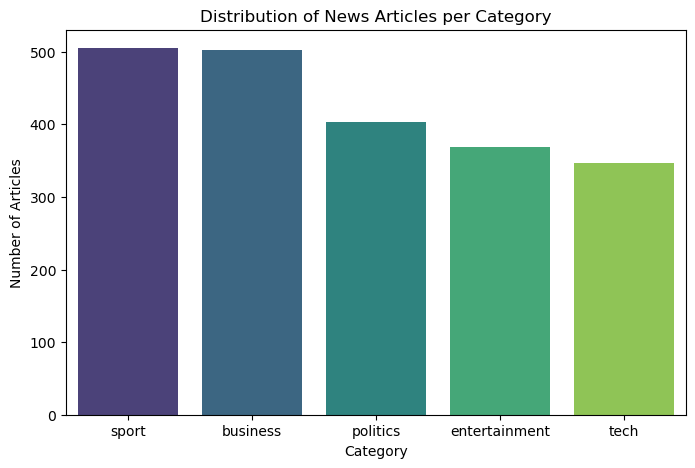

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of News Articles per Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.show()

### Text length analysis
Text length distribution is examined to understand document variability.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21252\2411562601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='word_count', palette = 'magma')


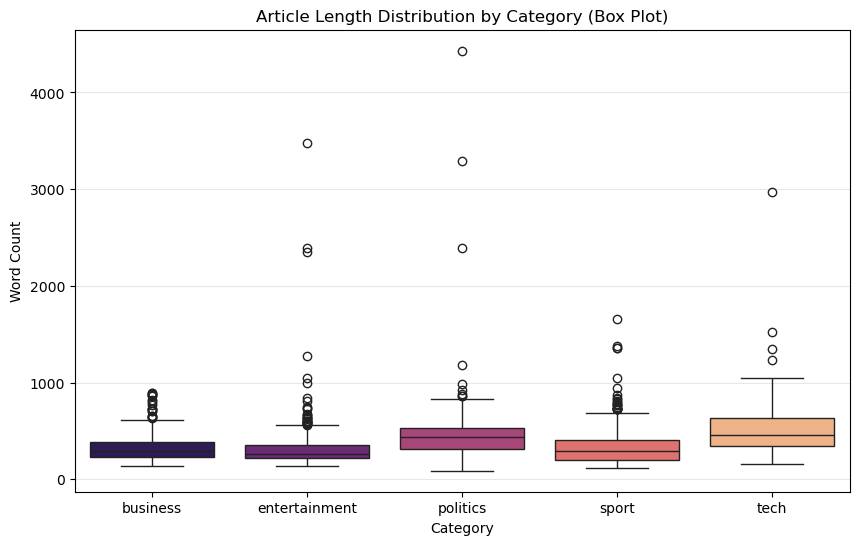

In [13]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count', palette = 'magma')
plt.title('Article Length Distribution by Category (Box Plot)')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Installing NLTK library

In [14]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [15]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [16]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Text Preprocessing
Initialize Stemmer and Stopwords

In [17]:

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

stop_words.update(['said', 'mr', 'would', 'year', 'also'])

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove non-alphabetic characters (punctuation/numbers)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Tokenize (split by space)
    words = text.split()
    
    # 4. Remove Stopwords and Apply Porter Stemming
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # Join back to string
    return " ".join(cleaned_words)

### Cleaning function
Text is normalized (lowercasing, punctuation removal, stopwords handling, stemming/_toggle as defined).

In [18]:
df['clean_text'] = df['text'].apply(preprocess_text)
df

,category,text,word_count,clean_text
0,business,Ad sales boost Time Warner profit\n\nQuarterly...,421,ad sale boost time warner profit quarterli pro...
1,business,Dollar gains on Greenspan speech\n\nThe dollar...,384,dollar gain greenspan speech dollar hit highes...
2,business,Yukos unit buyer faces loan claim\n\nThe owner...,264,yuko unit buyer face loan claim owner embattl ...
3,business,High fuel prices hit BA's profits\n\nBritish A...,406,high fuel price hit ba profit british airway b...
4,business,Pernod takeover talk lifts Domecq\n\nShares in...,265,pernod takeov talk lift domecq share uk drink ...
...,...,...,...,...
2219,tech,New consoles promise big problems\n\nMaking ga...,1001,new consol promis big problem make game futur ...
2220,tech,BT program to beat dialler scams\n\nBT is intr...,420,bt program beat dialler scam bt introduc two i...
2222,tech,Be careful how you code\n\nA new European dire...,1050,care code new european direct could put softwa...
2223,tech,US cyber security chief resigns\n\nThe man mak...,379,us cyber secur chief resign man make sure us c...


### Word clouds
Most frequent terms are visualized to get an intuitive sense of topic vocabulary.

In [19]:
from wordcloud import WordCloud

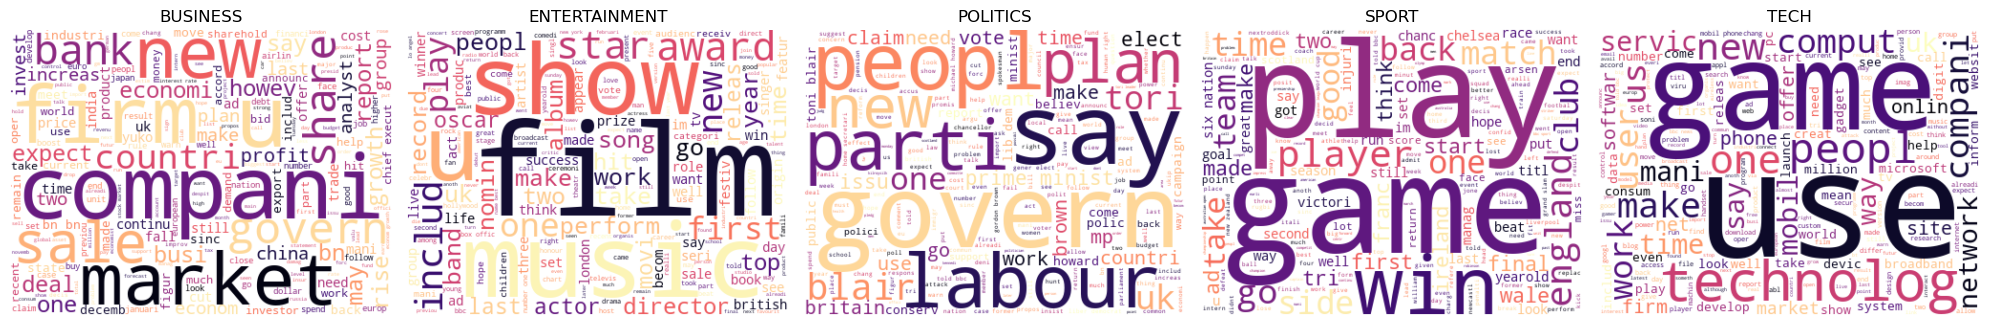

In [20]:
categories = df['category'].unique()
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, cat in enumerate(categories):
    
    subset = df[df['category'] == cat]
    text = " ".join(subset['clean_text'])

    wc = WordCloud(width=400, height=300, background_color='white', colormap='magma').generate(text)
    
    # Plot
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(cat.upper(), fontsize=12)

plt.tight_layout()
plt.show()

## Installing scikit-learn

In [21]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Vectorization
Text is converted into numeric features suitable for machine learning models.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [23]:
# Initialize TF-IDF 
tfidf = TfidfVectorizer(max_features=5000, min_df = 3)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['category']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.shape

(1701, 5000)

In [25]:
X_test.shape

(426, 5000)

## Model training (Multinomial NB)
Multinomial Naive Bayes classifier is trained on vectorized text features.



In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [27]:
# Train Model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [28]:
# Predict
y_pred_nb = nb_model.predict(X_test)

In [29]:
# Evaluate
nb_acc = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")
print("\nClassification Report (Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9648

Classification Report (Naive Bayes):

               precision    recall  f1-score   support

     business       0.97      0.98      0.98       104
entertainment       0.99      0.88      0.93        78
     politics       0.91      0.99      0.95        73
        sport       0.99      1.00      0.99        98
         tech       0.96      0.96      0.96        73

     accuracy                           0.96       426
    macro avg       0.96      0.96      0.96       426
 weighted avg       0.97      0.96      0.96       426



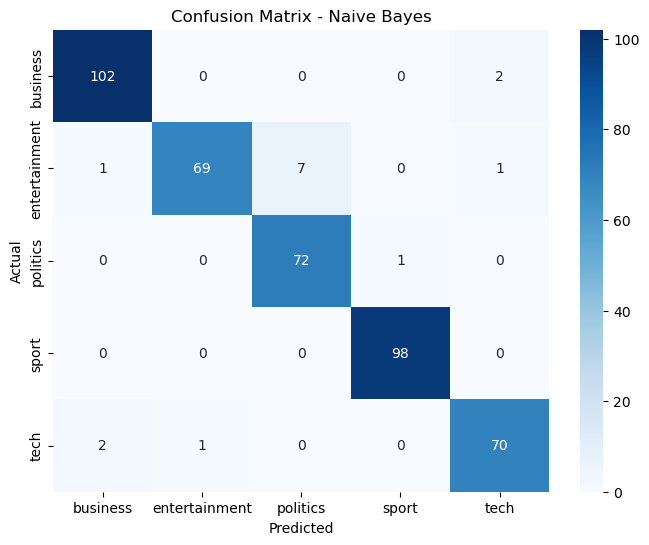

In [30]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model training (SVM)
Support Vector Classifier on vectorized text features.

In [31]:
from sklearn.svm import LinearSVC


In [32]:
# Train Model 
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [33]:
# Predict
y_pred_svm = svm_model.predict(X_test)

In [34]:
# Evaluate
svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_acc:.4f}")
print("\nClassification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9742

Classification Report (SVM):

               precision    recall  f1-score   support

     business       0.98      0.96      0.97       104
entertainment       0.97      0.94      0.95        78
     politics       0.96      0.99      0.97        73
        sport       0.99      1.00      0.99        98
         tech       0.96      0.99      0.97        73

     accuracy                           0.97       426
    macro avg       0.97      0.97      0.97       426
 weighted avg       0.97      0.97      0.97       426



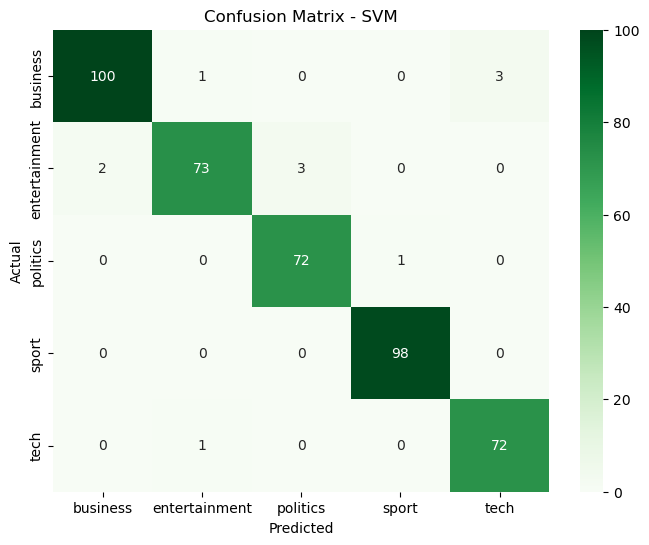

In [35]:
# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens', 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Top Features Visualization
Bar charts are created for top features from SVM model

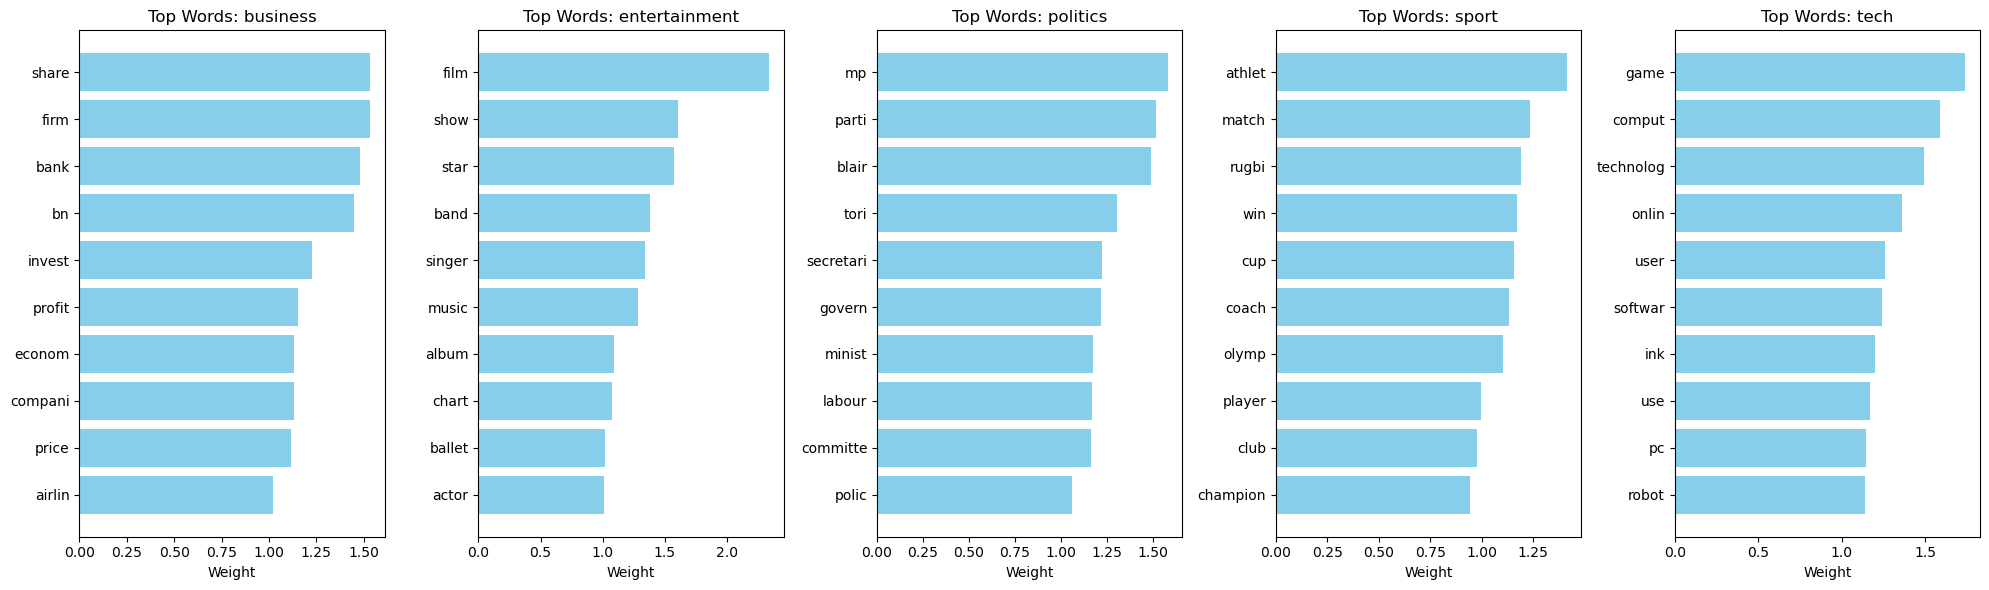

In [36]:
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
classes = svm_model.classes_

for i, class_label in enumerate(classes):
    
    top10_indices = svm_model.coef_[i].argsort()[-10:]
    top10_words = [feature_names[j] for j in top10_indices]
    top10_weights = svm_model.coef_[i][top10_indices]
    
 
    axes[i].barh(top10_words, top10_weights, color='skyblue')
    axes[i].set_title(f"Top Words: {class_label}")
    axes[i].set_xlabel("Weight")

plt.tight_layout()
plt.show()

#  ROC Curve


In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

classes = svm_model.classes_
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

y_score_nb = nb_model.predict_proba(X_test)

y_score_svm = svm_model.decision_function(X_test)


### PLot ROC Curve for each Class (Naive Bayes)

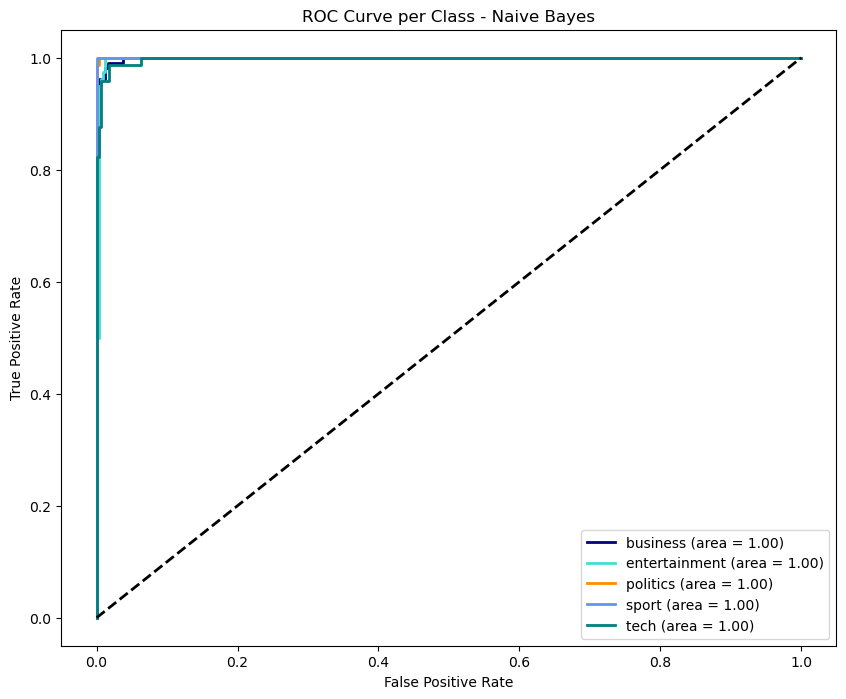

In [38]:
from itertools import cycle
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_nb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{classes[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class - Naive Bayes')
plt.legend(loc="lower right")
plt.show()

### PLot ROC Curve for each Class (SVM)

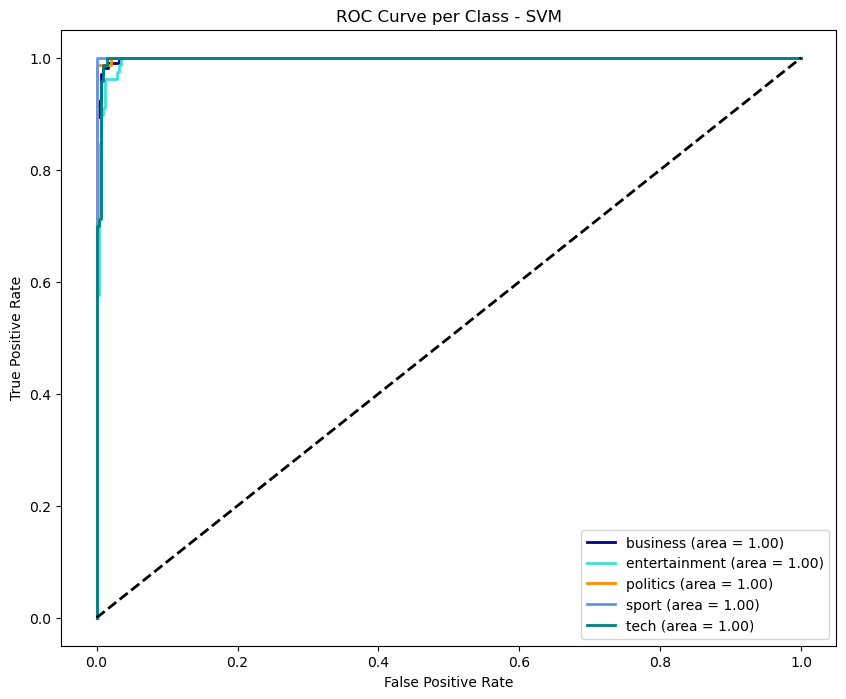

In [39]:

plt.figure(figsize=(10, 8))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{classes[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class - SVM')
plt.legend(loc="lower right")
plt.show()

### Comparative ROC (Micro-Average)

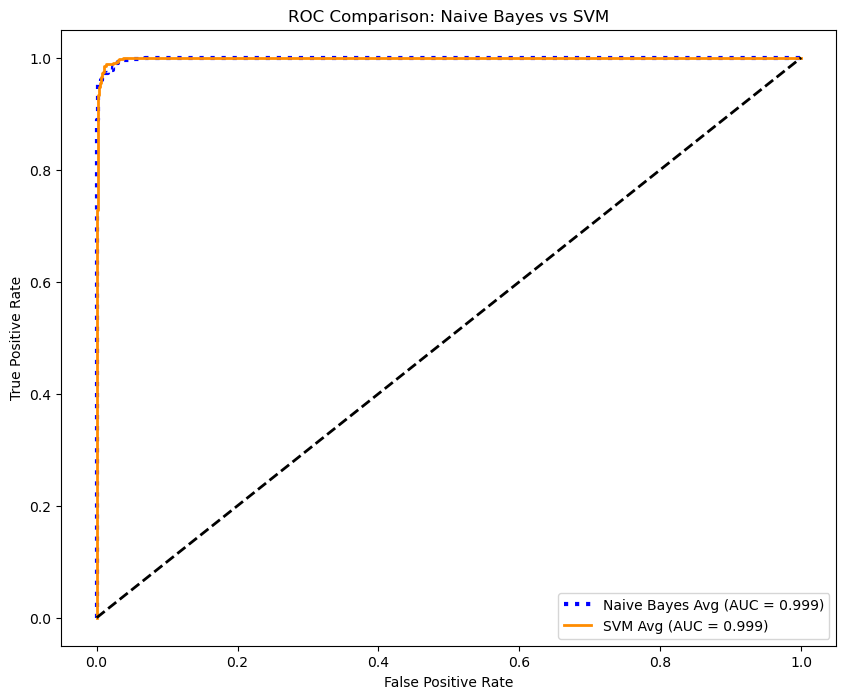

In [40]:

plt.figure(figsize=(10, 8))

# Naive Bayes Average
fpr_nb, tpr_nb, _ = roc_curve(y_test_bin.ravel(), y_score_nb.ravel())
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes Avg (AUC = {auc(fpr_nb, tpr_nb):.3f})', color='blue', linestyle=':', lw=3)

# SVM Average
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin.ravel(), y_score_svm.ravel())
plt.plot(fpr_svm, tpr_svm, label=f'SVM Avg (AUC = {auc(fpr_svm, tpr_svm):.3f})', color='darkorange', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Comparison: Naive Bayes vs SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

#  Precision-Recall Curve

### Plot PR Curve for each class (SVM Model)

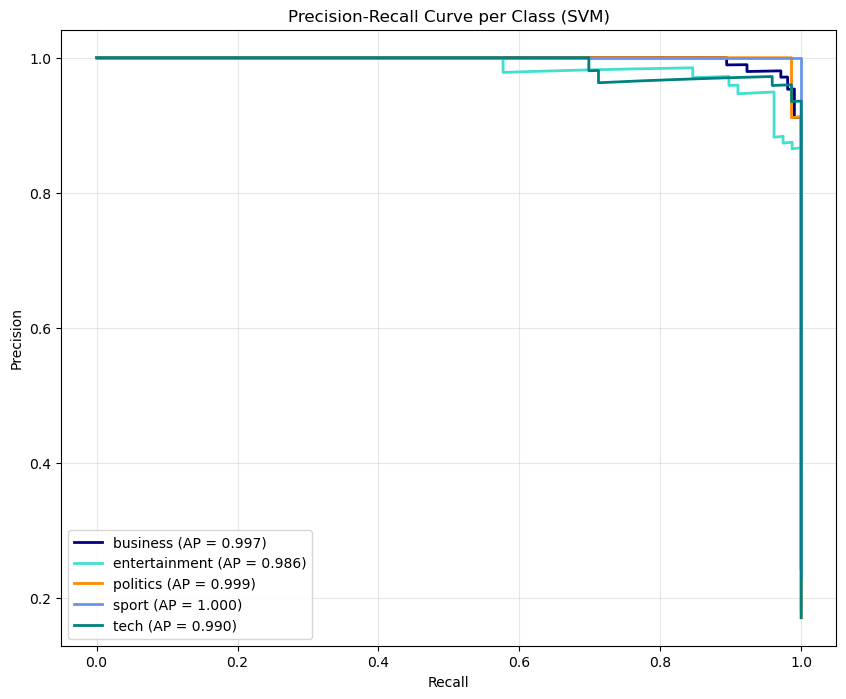

In [41]:
from itertools import cycle


plt.figure(figsize=(10, 8))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_svm[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_score_svm[:, i])
    
    plt.plot(recall, precision, color=color, lw=2,
             label=f'{classes[i]} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class (SVM)')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

### Plot PR Curve for each class (Naive Bayes Model)

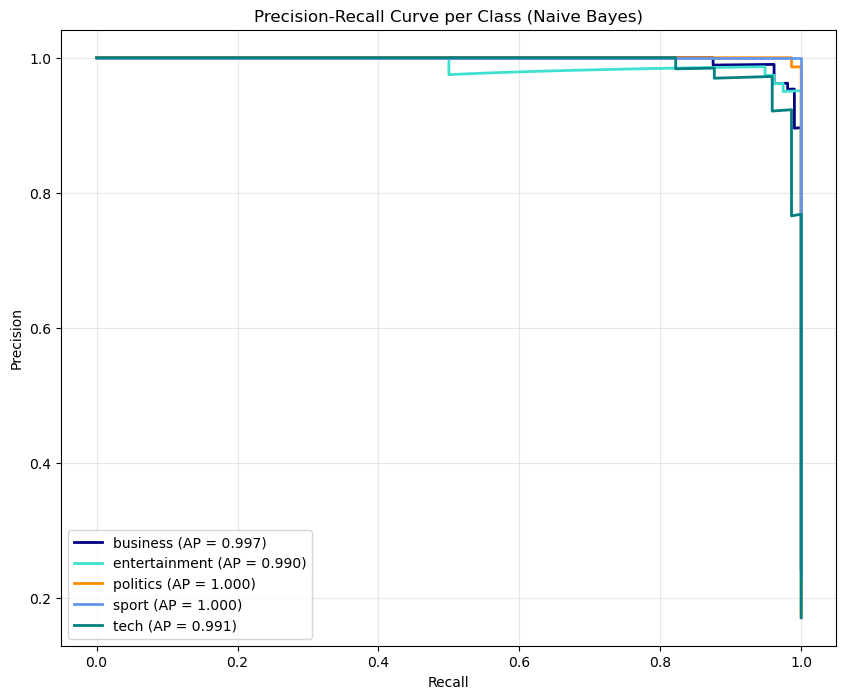

In [42]:

plt.figure(figsize=(10, 8))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])


for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_nb[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_score_nb[:, i])
    
    plt.plot(recall, precision, color=color, lw=2,
             label=f'{classes[i]} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class (Naive Bayes)')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

### Calculate Micro-Average Precision-Recall

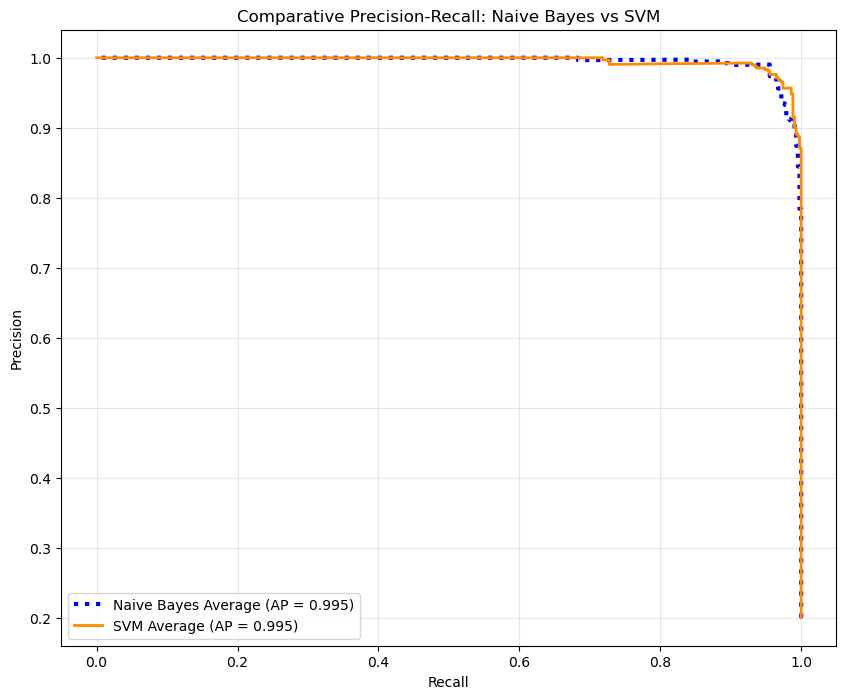

In [43]:

precision_nb_micro, recall_nb_micro, _ = precision_recall_curve(y_test_bin.ravel(), y_score_nb.ravel())
ap_nb_micro = average_precision_score(y_test_bin, y_score_nb, average="micro")

precision_svm_micro, recall_svm_micro, _ = precision_recall_curve(y_test_bin.ravel(), y_score_svm.ravel())
ap_svm_micro = average_precision_score(y_test_bin, y_score_svm, average="micro")


plt.figure(figsize=(10, 8))

plt.plot(recall_nb_micro, precision_nb_micro, 
         label=f'Naive Bayes Average (AP = {ap_nb_micro:.3f})',
         color='blue', linestyle=':', linewidth=3)

plt.plot(recall_svm_micro, precision_svm_micro, 
         label=f'SVM Average (AP = {ap_svm_micro:.3f})',
         color='darkorange', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparative Precision-Recall: Naive Bayes vs SVM')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

# Compare Accuracies

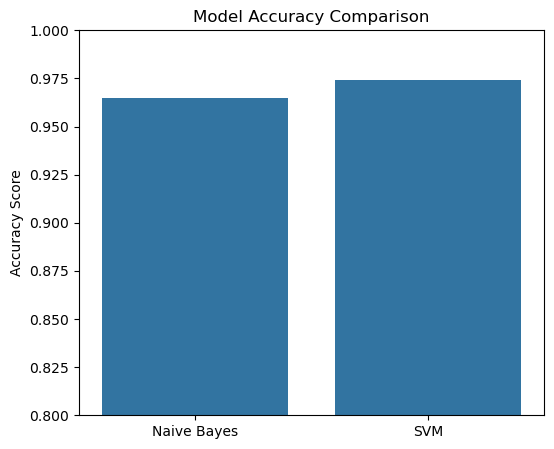

--- Prediction Test ---
Input Text: The stock market crashed today after the tech giant announced huge losses.
Naive Bayes Prediction: business
SVM Prediction: business


In [44]:
models = ['Naive Bayes', 'SVM']
accuracies = [nb_acc, svm_acc]

plt.figure(figsize=(6, 5))
sns.barplot(x=models, y=accuracies)
plt.ylim(0.8, 1.0) 
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.show()

sample_text = ["The stock market crashed today after the tech giant announced huge losses."]
sample_vec = tfidf.transform([preprocess_text(sample_text[0])])

pred_nb = nb_model.predict(sample_vec)[0]
pred_svm = svm_model.predict(sample_vec)[0]

print("--- Prediction Test ---")
print(f"Input Text: {sample_text[0]}")
print(f"Naive Bayes Prediction: {pred_nb}")
print(f"SVM Prediction: {pred_svm}")